In [353]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.rnaseqTools import geneSelection, sparseload
import pickle
import torch
import urllib.request
import requests
 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


# path

In [354]:
root_path = get_path("data")
fig_path = os.path.join(root_path, "figures")
seeds = [0]
k = 15

In [355]:
style_file = "utils.style"
plt.style.use(style_file)

In [400]:
distances = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    #     # {"k": 100, "t": 128, "kernel": "sknn", "include_self": False},
    #     # {"k": 200, "t": 64, "kernel": "sknn", "include_self": False},
    #     # {"k": 200, "t": 128, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        # {"corrected": True, "weighted": False, "k": 200, "disconnect": True},
        # {"corrected": True, "weighted": False, "k": 300, "disconnect": True},
    ],
}

In [357]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
# seed = 0
file_name = os.path.join(root_path,
                         "yao_10x_male",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_0_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [8]:
def compute_density(cell_list, cluster_template):
    lens = len(cell_list)
    density = []
    for cluster in cluster_template:
        count = cell_list.count(cluster)
        density.append(count)
    # print(density)
    density = np.array(density)/lens
    return density

# mask making

In [9]:
_, _, _, _, full_d = load_dataset(root_path, "yao_10x_male", k=k)

In [10]:
#cannot really find "Serpinf1", but on the paper according to fig 2D, it should be 21_ to 24_, and 41_ and 40_, so its already included in vip and Sncg
#but should i also included _Ntng1, according to fig 2D..... and lamp5_pax6 is labeled as "_Pax6, so i also added it in.... 
idx_purple = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
cluster_purple = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]


In [11]:
mask_purple = [idx in idx_purple for idx in full_d['clusters']]
idx_mask_purple = [i for i, idx in enumerate(full_d['clusters']) if idx in idx_purple ]


# distance sample then ph

In [417]:
x, y, sknn, pca2, d = load_dataset(root_path, "yao_10x_male_purple", k=15, seed=0)
all_res_sample = load_multiple_res(datasets="yao_10x_male_purple_0_10k", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
all_res_anosample = load_multiple_res(datasets="yao_10x_male_purple", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
new_all_res_sample = {key: value for distance in all_res_sample.values() for key, value in distance.items()}
new_all_res_anosample = {key: value for distance in all_res_anosample.values() for key, value in distance.items()}


new_all_res = {}
for key in list(new_all_res_sample.keys()):
# for key in set(new_all_res_sample) | set(new_all_res_anosample): 
    print(key)
    new_all_res[key] = {
        "sample before calculating distance": new_all_res_sample.get(key), 
        "sample after calculating distance": new_all_res_anosample.get(key)
    }



Done with yao_10x_male_purple_0_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_purple None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_purple None diffusion_k_15_t_8_kernel_sknn_include_self_

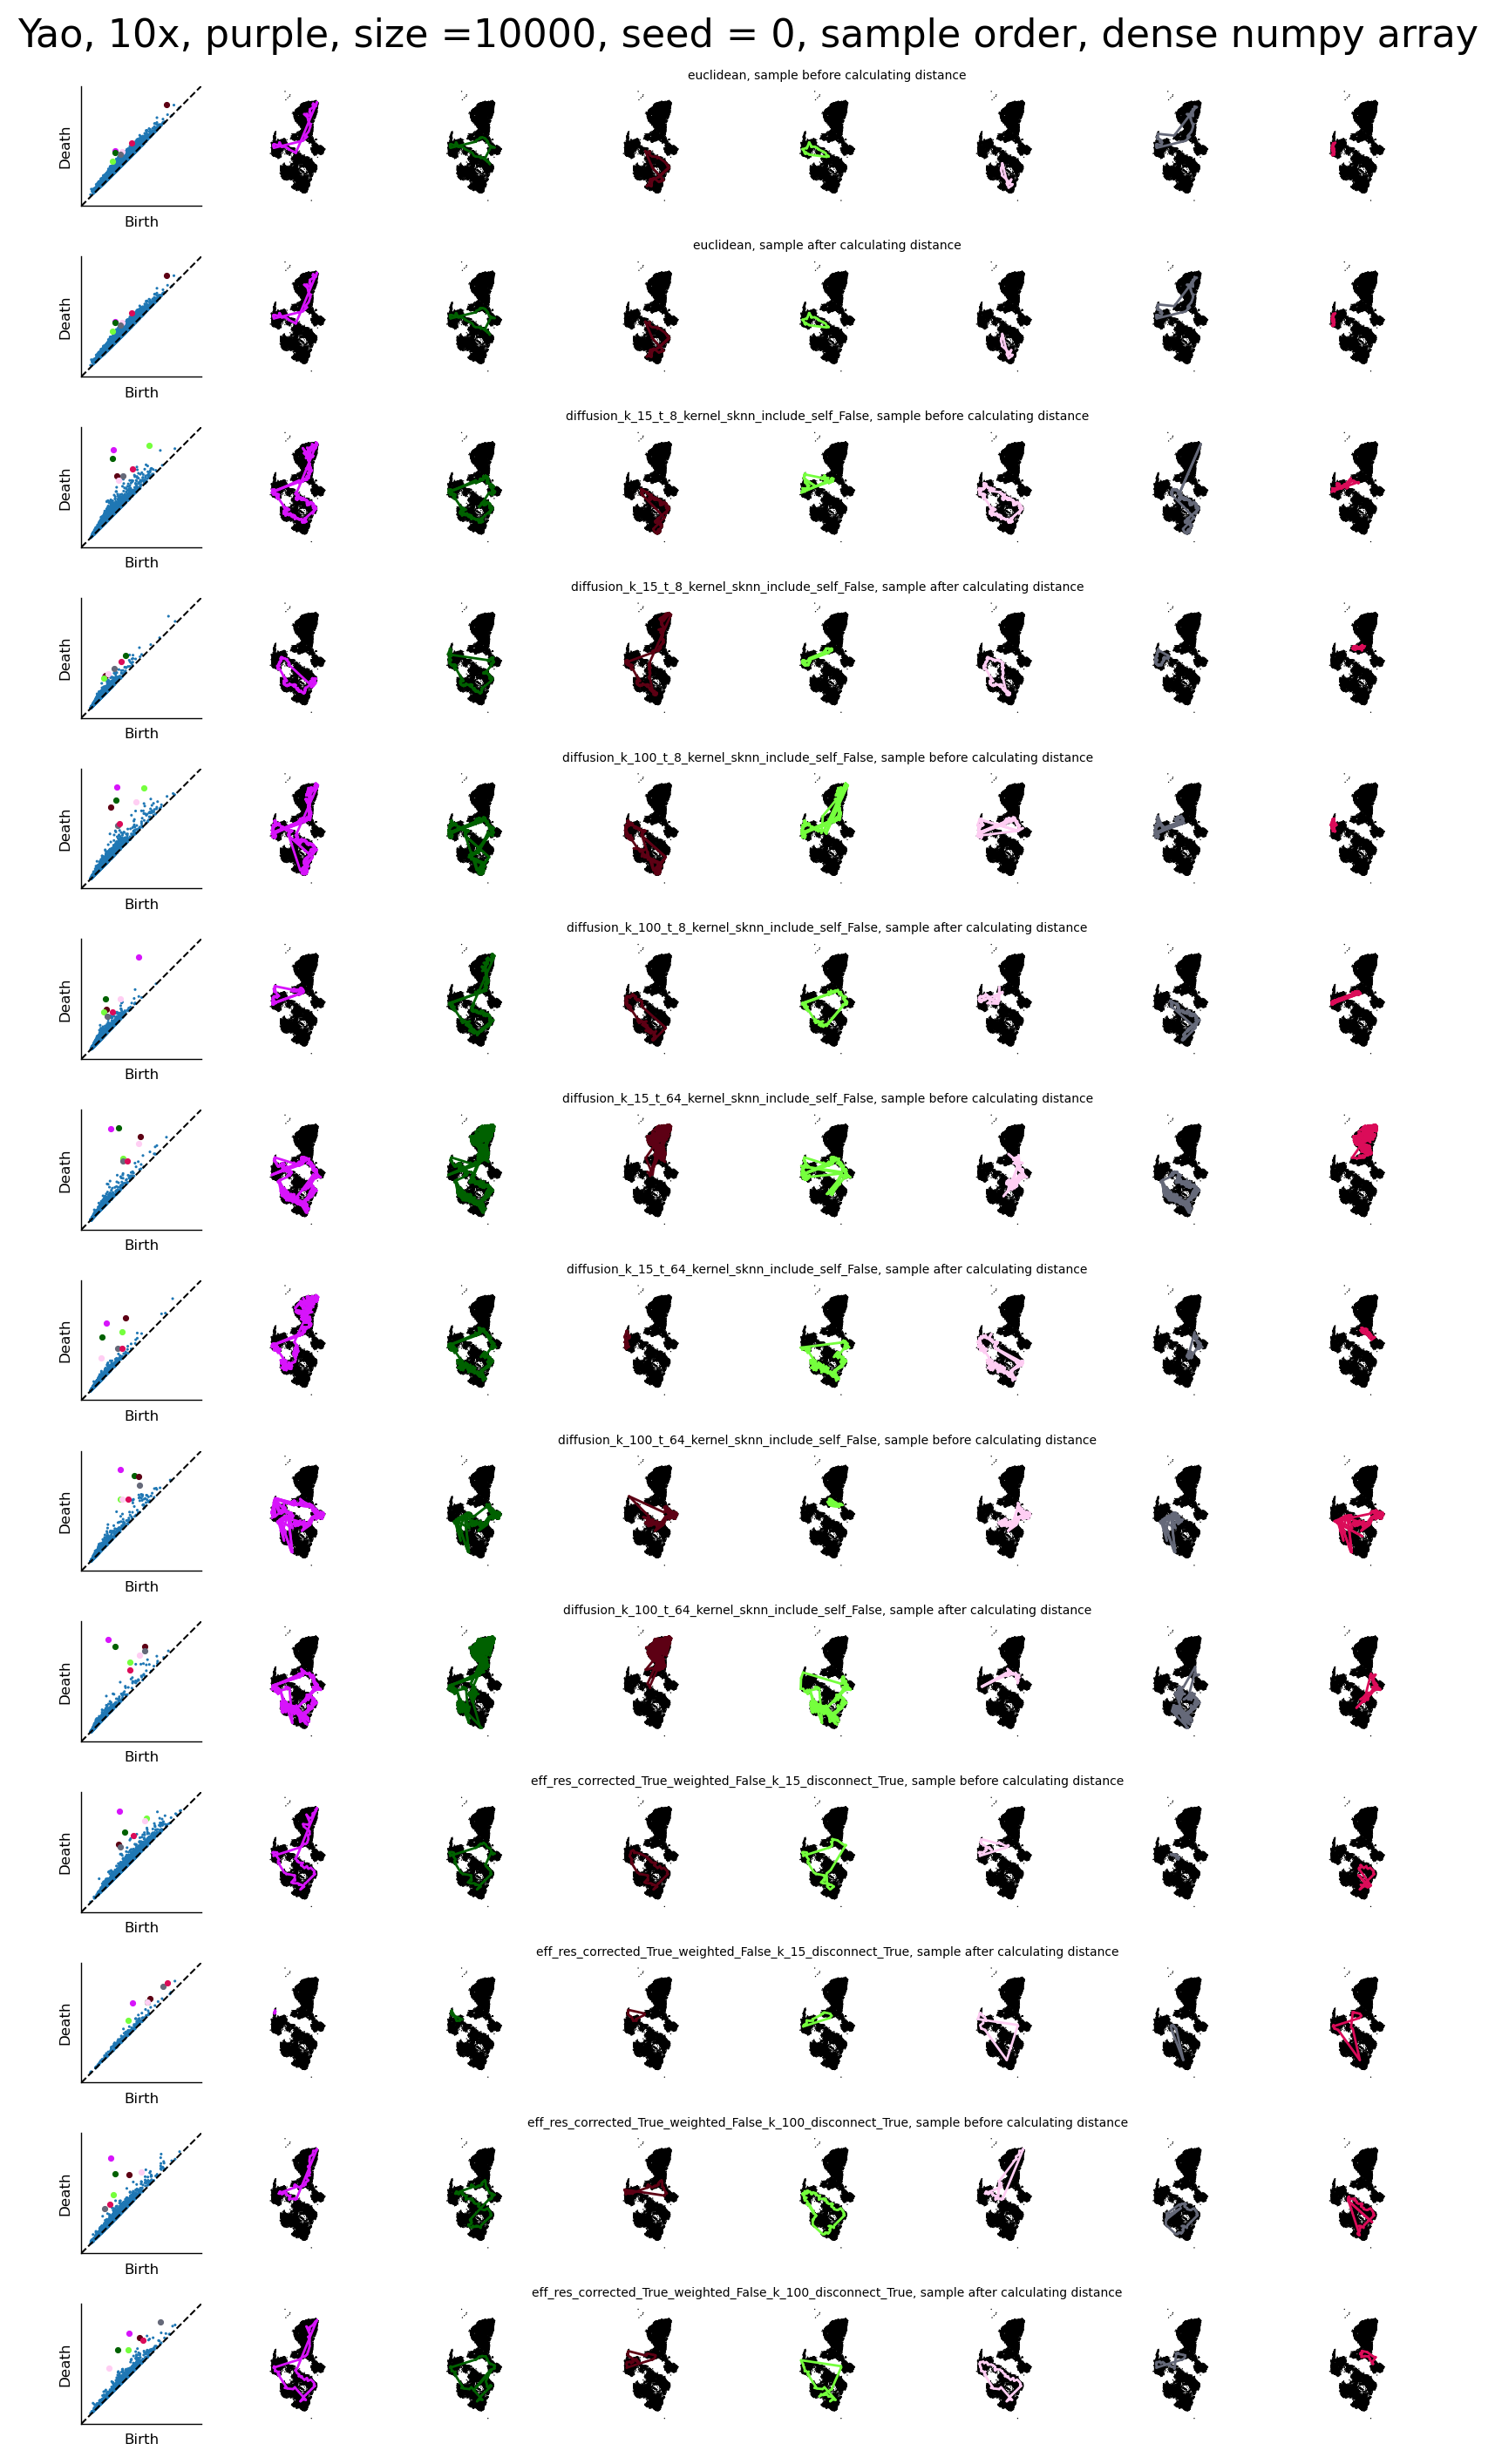

In [419]:
n_exp = 14
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, n_exp), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for full_dist in new_all_res.keys():
    for sample in new_all_res[full_dist]:
        res = new_all_res[full_dist][sample]    

        np.random.seed(0)
        mm_p = np.random.choice(len(idx_mask_purple), 20000, replace=False)
        ax[row][int(mid_col)].set_title(full_dist+", "+sample, fontsize=5) 
        plot_dgm_loops(res, embd[mask_purple][mm_p], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops) #mask_orange
        
        # for s in range(n_cols-1):
        #     ax[row][s+1].set_xlim(-65, -10)
        #     ax[row][s+1].set_ylim(20, 70)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        # ax[row][int(mid_col)].set_title(full_dist)
        row+=1
fig.suptitle("Yao, 10x, purple, size =10000, seed = 0, sample order, dense numpy array", fontsize = 16)       
plt.show()

fig.savefig(get_path("figures"), "purple_10x_sample_order.png"), dpi=300)
